### Установка связи с Kaggle и скачивание Dataset

In [ ]:
# Install kaggle
!pip install kaggle --quiet

In [ ]:
#  Upload kaggle.json file
from google.colab import files
files.upload()

Saving kaggle.json to kaggle (1).json


{'kaggle (1).json': b'{"username":"prostokyst","key":"2bd01cdcd9fb651083712b44e0521e74"}'}

In [ ]:
# Settings API kaggle
!mkdir ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

mkdir: cannot create directory ‘/root/.kaggle’: File exists


In [ ]:
# Download the dataset
import kagglehub

path = kagglehub.dataset_download("zlatan599/garbage-dataset-classification")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'garbage-dataset-classification' dataset.
Path to dataset files: /kaggle/input/garbage-dataset-classification


### Создание **DataFrame**, *распределение на классы и на выборки.*

> Подключение библиотек



In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import precision_recall_curve, classification_report
from sklearn.utils import class_weight
import matplotlib.pyplot as plt
import tensorflow as tf
import seaborn as sns
from PIL import Image
import pandas as pd
import numpy as np
import hashlib
import random
import os

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
# Coздаем DataFrame с изображениями
metadata_path = os.path.join(path, 'Garbage_Dataset_Classification', 'metadata.csv')
metadata_df = pd.read_csv(metadata_path)

print(metadata_df.head())
print("\n Распределение классов в датасете:")
print(metadata_df['label'].value_counts())

              filename      label
0  cardboard_02038.jpg  cardboard
1  cardboard_02320.jpg  cardboard
2  cardboard_01728.jpg  cardboard
3  cardboard_00093.jpg  cardboard
4  cardboard_00094.jpg  cardboard

 Распределение классов в датасете:
label
trash        2500
glass        2500
paper        2315
plastic      2288
cardboard    2214
metal        2084
Name: count, dtype: int64


In [ ]:
# # Проверяем распределение классов
# print("Распределение классов в датасете:")
# print(metadata_df['label'].value_counts())

# # Проверяем, где лежат сами картинки
# images_base_path = os.path.join(path, 'Garbage_Dataset_Classification', 'images')
# if os.path.exists(images_base_path):
#     print(f"\nПапка с изображениями найдена: {images_base_path}")
#     print("Пример файлов в папке:", os.listdir(images_base_path)[:5])
# else:
#     print(f"\nПапка {images_base_path} не найдена. Давай поищем, где лежат .jpg файлы.")

### Очистка данных (Битые файлы и дубликаты)

In [ ]:
broken_images = []
image_hashes = {}
duplicate_images = []

# Сначала создаем полные пути, чтобы проверить файлы
images_base_path = os.path.join(path, 'Garbage_Dataset_Classification', 'images')
metadata_df['full_path'] = metadata_df.apply(lambda row: os.path.join(images_base_path, row['label'], row['filename']), axis=1)

print("Проверка целостности и поиск дубликатов...")

for idx, row in metadata_df.iterrows():
    filepath = row['full_path']
    if not os.path.exists(filepath):
        broken_images.append(filepath)
        continue

    try:
        # Проверка открытия и целостности
        with Image.open(filepath) as img:
            img.verify()

        # Хеширование для поиска дубликатов
        with Image.open(filepath) as img:
            img_rgb = img.convert('RGB')
            img_hash = hashlib.md5(img_rgb.tobytes()).hexdigest()

            if img_hash in image_hashes:
                duplicate_images.append(filepath)
            else:
                image_hashes[img_hash] = filepath
    except Exception as e:
        broken_images.append(filepath)

all_to_remove = set(broken_images + duplicate_images)
print(f"Найдено битых: {len(broken_images)}, дубликатов: {len(duplicate_images)}")

# Окончательно очищаем основной DataFrame
metadata_df = metadata_df[~metadata_df['full_path'].isin(all_to_remove)].reset_index(drop=True)
print(f"Чистый размер датасета: {len(metadata_df)}")
print(f"Оставшиеся классы: {metadata_df['label'].unique()}")

Проверка целостности и поиск дубликатов...
Найдено битых: 0, дубликатов: 2244
Чистый размер датасета: 11657
Оставшиеся классы: ['cardboard' 'plastic' 'glass' 'metal' 'trash' 'paper']


In [ ]:
# 1. Фильтрация категорий
req_classes = ['paper', 'plastic', 'glass', 'metal']
metadata_df = metadata_df[metadata_df['label'].isin(req_classes)].reset_index(drop=True)

print(f"Размер датасета после фильтрации классов: {len(metadata_df)}")
print(f"Используемые классы: {metadata_df['label'].unique()}")

Размер датасета после фильтрации классов: 7439
Используемые классы: ['plastic' 'glass' 'metal' 'paper']


In [ ]:
# 2. Разделение на обучающую и тестовую выборки
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    metadata_df,
    test_size=0.25,
    stratify=metadata_df['label'],
    random_state=42
)

print(f"Размер обучающей выборки: {len(train_df)}")
print(f"Размер тестовой выборки: {len(test_df)}")

Размер обучающей выборки: 5579
Размер тестовой выборки: 1860


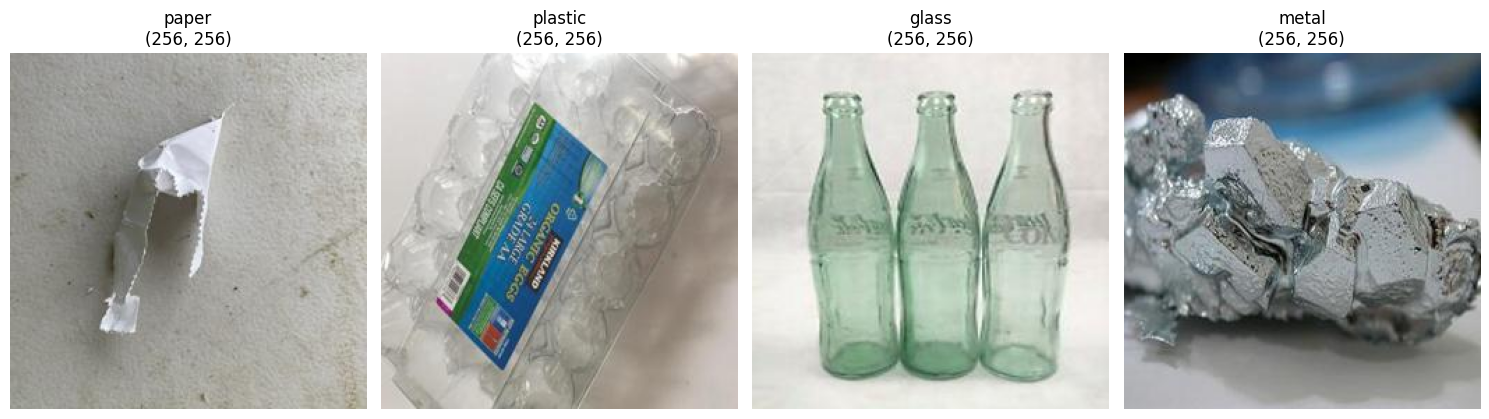

In [ ]:
# Визуализация примеров из наших 4 категорий
classes = ['paper', 'plastic', 'glass', 'metal']
fig, axs = plt.subplots(1, 4, figsize=(15, 5))

for i, label in enumerate(classes):
    class_df = train_df[train_df['label'] == label]
    if not class_df.empty:
        img_path = random.choice(class_df['full_path'].tolist())
        try:
            img = Image.open(img_path)
            axs[i].imshow(img)
            axs[i].set_title(f"{label}\n{img.size}")
            axs[i].axis('off')
        except Exception as e:
            print(f"Ошибка загрузки {img_path}: {e}")

plt.tight_layout()
plt.show()

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# Улучшенная аугментация (добавлена яркость для распознавания металла)
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    brightness_range=[0.7, 1.3], # Помогает при плохом освещении камеры
    horizontal_flip=True,
    fill_mode='nearest'
)

# Для теста только рескейл
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_dataframe(
    train_df,
    x_col='full_path',
    y_col='label',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    classes=classes
)

test_generator = test_datagen.flow_from_dataframe(
    test_df,
    x_col='full_path',
    y_col='label',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    classes=classes,
    shuffle=False
)

Found 5579 validated image filenames belonging to 4 classes.
Found 1860 validated image filenames belonging to 4 classes.


### Создание улучшенной модели MobileNetV2
Добавляем слои GlobalAveragePooling и Dropout для стабильности.

In [ ]:
# Загружаем предобученную модель
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Замораживаем базовые слои
base_model.trainable = False

# Добавляем новые слои
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(512, activation='relu')(x)
x = Dropout(0.3)(x)  # Помогает от переобучения
predictions = Dense(len(classes), activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

model.compile(optimizer=Adam(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,915,908 (11.12 MB)

 Trainable params: 657,924 (2.51 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

### Запуск обучения (Head Training)
Обучаем только верхние слои в течение 10 эпох. Используем `EarlyStopping`, чтобы не переобучить модель, если точность перестанет расти.

In [ ]:
# Остановим обучение, если точность на валидации не растет 3 эпохи
early_stop = EarlyStopping(monitor='val_accuracy', patience=3, restore_best_weights=True)

epochs = 10

history = model.fit(
    train_generator,
    validation_data=test_generator,
    epochs=epochs,
    callbacks=[early_stop]
)

Epoch 1/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 383s 2s/step - accuracy: 0.7942 - loss: 0.5596 - val_accuracy: 0.8618 - val_loss: 0.3745
Epoch 2/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 377s 2s/step - accuracy: 0.8570 - loss: 0.3898 - val_accuracy: 0.8737 - val_loss: 0.3458
Epoch 3/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 380s 2s/step - accuracy: 0.8668 - loss: 0.3496 - val_accuracy: 0.8677 - val_loss: 0.3569
Epoch 4/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 383s 2s/step - accuracy: 0.8837 - loss: 0.3182 - val_accuracy: 0.8774 - val_loss: 0.3221
Epoch 5/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 441s 2s/step - accuracy: 0.8966 - loss: 0.2745 - val_accuracy: 0.8898 - val_loss: 0.2991
Epoch 6/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 377s 2s/step - accuracy: 0.8962 - loss: 0.2618 - val_accuracy: 0.8914 - val_loss: 0.3001
Epoch 7/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 381s 2s/step - accuracy: 0.9063 - loss: 0.2452 - val_accuracy: 0.8968 - val_loss: 0.2851
Epoch 8/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 377s 2s/step - accuracy: 0.9165 - loss: 0.2292 - val_accu

### Визуализация процесса обучения
Построим графики точности и потерь для анализа переобучения.

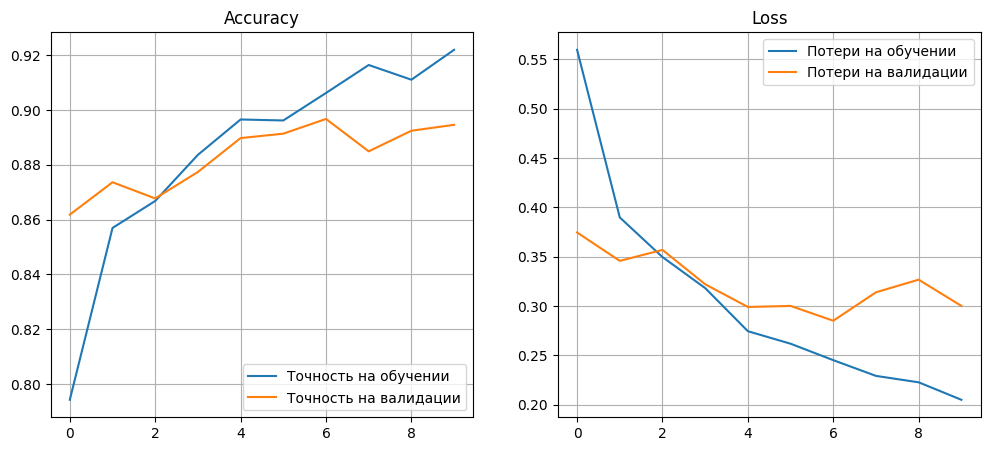

In [ ]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(12, 5))

# График точности
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Точность на обучении')
plt.plot(epochs_range, val_acc, label='Точность на валидации')
plt.title('Accuracy')
plt.legend(loc='lower right')
plt.grid(True)

# График потерь
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Потери на обучении')
plt.plot(epochs_range, val_loss, label='Потери на валидации')
plt.title('Loss')
plt.legend(loc='upper right')
plt.grid(True)

plt.show()

### Разморозка слоев и Fine-tuning
Теперь мы разморозим часть базовой модели, чтобы она лучше адаптировалась к специфическим текстурам металла и пластика.

In [ ]:
# Размораживаем все слои базовой модели
base_model.trainable = True

# Посмотрим, сколько всего слоев в базовой модели
print(f"Количество слоев в базовой модели: {len(base_model.layers)}")

# Заморозим все слои до 100-го (оставим обучаемыми только верхние слои для тонкой настройки)
fine_tune_at = 100
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

# Для Fine-tuning ОБЯЗАТЕЛЬНО используем маленький learning_rate
model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

Количество слоев в базовой модели: 154


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,915,908 (11.12 MB)

 Trainable params: 2,519,364 (9.61 MB)

 Non-trainable params: 396,544 (1.51 MB)

In [ ]:
# Дообучаем еще 10 эпох
fine_tune_epochs = 10
total_epochs = epochs + fine_tune_epochs

history_fine = model.fit(
    train_generator,
    validation_data=test_generator,
    epochs=total_epochs,
    initial_epoch=history.epoch[-1], # Продолжаем с того места, где остановились
    callbacks=[early_stop]
)

Epoch 10/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 550s 3s/step - accuracy: 0.8605 - loss: 0.3704 - val_accuracy: 0.8328 - val_loss: 0.5607
Epoch 11/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 535s 3s/step - accuracy: 0.9046 - loss: 0.2502 - val_accuracy: 0.8737 - val_loss: 0.3806
Epoch 12/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 526s 3s/step - accuracy: 0.9376 - loss: 0.1780 - val_accuracy: 0.9124 - val_loss: 0.2861
Epoch 13/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 529s 3s/step - accuracy: 0.9401 - loss: 0.1588 - val_accuracy: 0.8995 - val_loss: 0.3194
Epoch 14/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 556s 3s/step - accuracy: 0.9559 - loss: 0.1270 - val_accuracy: 0.9124 - val_loss: 0.2989
Epoch 15/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 539s 3s/step - accuracy: 0.9591 - loss: 0.1105 - val_accuracy: 0.8505 - val_loss: 0.5268


### Визуализация процесса Fine-tuning
Посмотрим, как изменились метрики после разморозки слоев базовой модели.

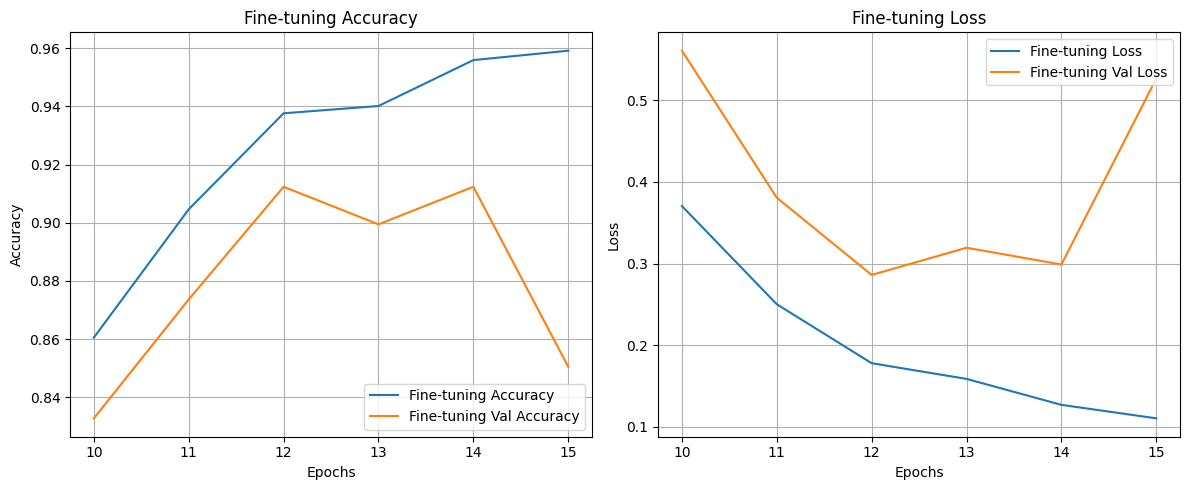

In [ ]:
acc_fine = history_fine.history['accuracy']
val_acc_fine = history_fine.history['val_accuracy']
loss_fine = history_fine.history['loss']
val_loss_fine = history_fine.history['val_loss']

# Индексы эпох для графика (продолжаем нумерацию)
epochs_range_fine = range(history.epoch[-1] + 1, history.epoch[-1] + 1 + len(acc_fine))

plt.figure(figsize=(12, 5))

# График точности
plt.subplot(1, 2, 1)
plt.plot(epochs_range_fine, acc_fine, label='Fine-tuning Accuracy')
plt.plot(epochs_range_fine, val_acc_fine, label='Fine-tuning Val Accuracy')
plt.title('Fine-tuning Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True)

# График потерь
plt.subplot(1, 2, 2)
plt.plot(epochs_range_fine, loss_fine, label='Fine-tuning Loss')
plt.plot(epochs_range_fine, val_loss_fine, label='Fine-tuning Val Loss')
plt.title('Fine-tuning Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True)

plt.tight_layout()
plt.show()

### Оценка модели: Матрица ошибок
Чтобы понять, почему металл путается с другими классами, построим матрицу ошибок на тестовой выборке.

59/59 ━━━━━━━━━━━━━━━━━━━━ 83s 1s/step
Classification Report
              precision    recall  f1-score   support

       paper       0.98      0.94      0.96       452
     plastic       0.85      0.89      0.87       428
       glass       0.93      0.91      0.92       573
       metal       0.89      0.90      0.90       407

    accuracy                           0.91      1860
   macro avg       0.91      0.91      0.91      1860
weighted avg       0.91      0.91      0.91      1860



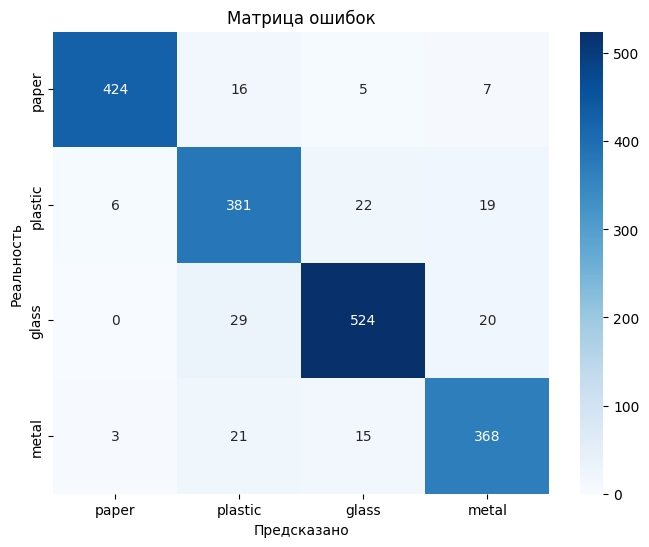

In [ ]:
# Получаем предсказания на тестовой логике
test_generator.reset()
Y_pred = model.predict(test_generator)
y_pred = np.argmax(Y_pred, axis=1)

# Печатаем отчет
print('Classification Report')
print(classification_report(test_generator.classes, y_pred, target_names=classes))

# Строим матрицу
cm = confusion_matrix(test_generator.classes, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=classes, yticklabels=classes, cmap='Blues')
plt.xlabel('Предсказано')
plt.ylabel('Реальность')
plt.title('Матрица ошибок')
plt.show()

### Расчет весов классов для улучшения распознавания 'проблемных' категорий
Если модель плохо видит металл, мы дадим этому классу больший вес при обучении.

In [ ]:
# Получаем список всех меток из обучающей выборки
y_train = train_generator.classes

# Вычисляем веса (чем меньше примеров или хуже точность, тем выше вес)
weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights = dict(enumerate(weights))

# Ручная корректировка: увеличим вес для металла (индекс 3 в нашем списке classes)
# Это заставит модель меньше игнорировать признаки металла
class_weights[3] = class_weights[3] * 1.5

print("Веса классов для обучения:", {classes[i]: class_weights[i] for i in class_weights})

Веса классов для обучения: {'paper': np.float64(1.0278187177597642), 'plastic': np.float64(1.0879485179407176), 'glass': np.float64(0.8109011627906977), 'metal': np.float64(1.7148565573770493)}


### Финальная корректировка модели с весами классов
Дообучаем модель 5 эпох, чтобы она сфокусировалась на металле и пластике.

In [ ]:
# Запускаем короткое дообучение с параметром class_weight
final_history = model.fit(
    train_generator,
    validation_data=test_generator,
    epochs=5,
    class_weight=class_weights,
    callbacks=[early_stop]
)

print("Дообучение завершено. Теперь можно обновлять TFLite модель.")

Epoch 1/5
175/175 ━━━━━━━━━━━━━━━━━━━━ 545s 3s/step - accuracy: 0.9392 - loss: 0.1889 - val_accuracy: 0.8962 - val_loss: 0.3611
Epoch 2/5
175/175 ━━━━━━━━━━━━━━━━━━━━ 545s 3s/step - accuracy: 0.9450 - loss: 0.1621 - val_accuracy: 0.8984 - val_loss: 0.3449
Epoch 3/5
175/175 ━━━━━━━━━━━━━━━━━━━━ 542s 3s/step - accuracy: 0.9566 - loss: 0.1368 - val_accuracy: 0.8430 - val_loss: 0.6135
Дообучение завершено. Теперь можно обновлять TFLite модель.


### Финальная проверка после взвешивания классов
Мы проверяем итоговые метрики, чтобы убедиться, что модель правильно определяет металл и пластик, сохраняя при этом высокую точность для других классов.

59/59 ━━━━━━━━━━━━━━━━━━━━ 77s 1s/step
Final Classification Report (With Class Weights):
              precision    recall  f1-score   support

       paper       0.99      0.93      0.96       452
     plastic       0.76      0.92      0.83       428
       glass       0.97      0.84      0.90       573
       metal       0.88      0.91      0.89       407

    accuracy                           0.90      1860
   macro avg       0.90      0.90      0.90      1860
weighted avg       0.91      0.90      0.90      1860



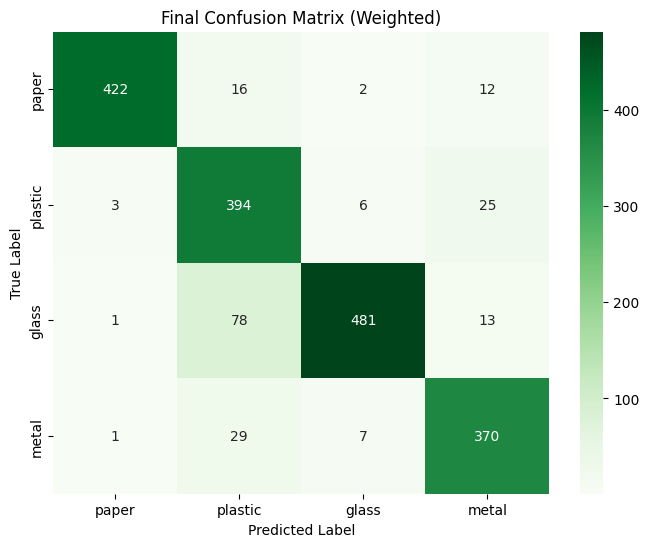

In [ ]:
# Reset test generator to ensure clean results
test_generator.reset()

# Get predictions
Y_pred = model.predict(test_generator)
y_pred = np.argmax(Y_pred, axis=1)

# Print detailed report
print('Final Classification Report (With Class Weights):')
print(classification_report(test_generator.classes, y_pred, target_names=classes))

# Plot Confusion Matrix
cm = confusion_matrix(test_generator.classes, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=classes, yticklabels=classes, cmap='Greens')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Final Confusion Matrix (Weighted)')
plt.show()

### Оптимизация порогов классификации
Вместо стандартного выбора максимальной вероятности, мы подберем пороги так, чтобы минимизировать ложные срабатывания для пластика.

In [ ]:
# Получаем вероятности для всех классов (Y_probs уже доступен в ядре)
Y_probs = model.predict(test_generator)

# Индекс класса 'plastic'
plastic_class_idx = classes.index('plastic')

# Истинные метки для пластика (1 если пластик, 0 в противном случае)
true_plastic = (np.array(test_generator.classes) == plastic_class_idx).astype(int)
probs_plastic = Y_probs[:, plastic_class_idx]

# Вычисляем precision, recall и thresholds для пластика
precision, recall, thresholds = precision_recall_curve(true_plastic, probs_plastic)

# Вычисляем F1-меру для каждого порога
# precision[:-1] и recall[:-1] соответствуют thresholds
f1_scores = (2 * precision[:-1] * recall[:-1]) / (precision[:-1] + recall[:-1])
f1_scores = np.nan_to_num(f1_scores) # Обрабатываем потенциальные NaN (0/0)

# Находим порог, который максимизирует F1-меру для пластика
if len(f1_scores) > 0:
    optimal_threshold_idx = np.argmax(f1_scores)
    optimal_threshold = thresholds[optimal_threshold_idx]
    print(f"Оптимальный порог для класса 'plastic' (на основе F1-score): {optimal_threshold:.4f}")
else:
    optimal_threshold = 0.5 # Значение по умолчанию, если не удалось найти
    print(f"Не удалось найти оптимальный порог для 'plastic'. Используем значение по умолчанию: {optimal_threshold:.4f}")

# Определяем функцию для применения оптимального порога
def predict_with_optimized_plastic_threshold(probs, plastic_idx, opt_thresh):
    predictions = []
    for p in probs:
        # Если вероятность пластика выше или равна оптимальному порогу, классифицируем как пластик
        if p[plastic_idx] >= opt_thresh:
            predictions.append(plastic_idx)
        else:
            # Иначе, находим класс с максимальной вероятностью среди остальных классов
            temp_p = np.copy(p)
            temp_p[plastic_idx] = -1.0 # Временно устанавливаем низкую вероятность для пластика
            predictions.append(np.argmax(temp_p))
    return np.array(predictions)

# Применяем оптимизированный порог
y_pred_optimal_plastic = predict_with_optimized_plastic_threshold(
    Y_probs, plastic_class_idx, optimal_threshold
)

print('\nОтчет по классификации с оптимальным порогом для пластика:')
print(classification_report(test_generator.classes, y_pred_optimal_plastic, target_names=classes))

Оптимальный порог для класса 'plastic' (на основе F1-score): 0.7918

Отчет по классификации с оптимальным порогом для пластика:
              precision    recall  f1-score   support

       paper       0.98      0.94      0.96       452
     plastic       0.85      0.88      0.87       428
       glass       0.96      0.90      0.93       573
       metal       0.86      0.94      0.90       407

    accuracy                           0.91      1860
   macro avg       0.91      0.91      0.91      1860
weighted avg       0.92      0.91      0.91      1860



### Визуализация Precision-Recall для Пластика
Этот график поможет нам найти идеальный баланс: какой порог уверенности нужен, чтобы точность (precision) стала выше 0.80.

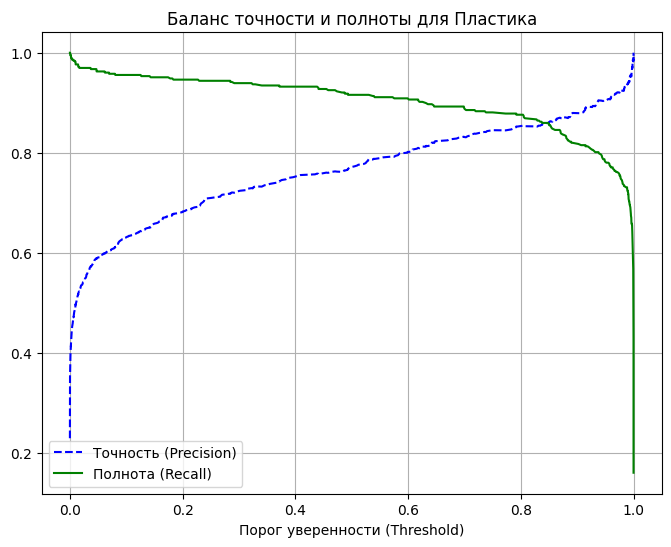

In [ ]:
# Индекс пластика - 1
probs_plastic = Y_probs[:, 1]
# Исправленная строка: приводим к numpy array перед использованием astype
true_plastic = (np.array(test_generator.classes) == 1).astype(int)

precision, recall, thresholds = precision_recall_curve(true_plastic, probs_plastic)

plt.figure(figsize=(8, 6))
plt.plot(thresholds, precision[:-1], 'b--', label='Точность (Precision)')
plt.plot(thresholds, recall[:-1], 'g-', label='Полнота (Recall)')
plt.xlabel('Порог уверенности (Threshold)')
plt.title('Баланс точности и полноты для Пластика')
plt.legend()
plt.grid(True)
plt.show()

### Конвертация в TFLite для Raspberry Pi
Для работы в реальном времени на процессоре ARM (Raspberry Pi) лучше всего использовать формат TensorFlow Lite и ее сохранение

In [ ]:
# Сохраняем модель в формате Keras
model.save('Sortify.h5')

converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

with open('Sortify', 'wb') as f:
    f.write(tflite_model)

print("Модель успешно сохранена как 'Sortify.h5' и конвертирована в 'Sortify.tflite'")# Сохраняем модель в формате Keras
model.save('Sortify.h5')

converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

with open('Sortify', 'wb') as f:
    f.write(tflite_model)

print("Модель успешно сохранена как 'Sortify.h5' и конвертирована в 'Sortify.tflite'")# Сохраняем модель в формате Keras
model.save('Sortify.h5')

converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

with open('Sortify', 'wb') as f:
    f.write(tflite_model)

print("Модель успешно сохранена как 'Sortify.h5' и конвертирована в 'Sortify.tflite'")# Сохраняем модель в формате Keras
model.save('Sortify.h5')

converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

with open('Sortify', 'wb') as f:
    f.write(tflite_model)

print("Модель успешно сохранена как 'Sortify.h5' и конвертирована в 'Sortify.tflite'")# Сохраняем модель в формате Keras
model.save('Sortify.h5')

converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

with open('Sortify', 'wb') as f:
    f.write(tflite_model)

print("Модель успешно сохранена как 'Sortify.h5' и конвертирована в 'Sortify.tflite'")# Сохраняем модель в формате Keras
model.save('Sortify.h5')

converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

with open('Sortify', 'wb') as f:
    f.write(tflite_model)

print("Модель успешно сохранена как 'Sortify.h5' и конвертирована в 'Sortify.tflite'")# Сохраняем модель в формате Keras
model.save('Sortify.h5')

converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

with open('Sortify', 'wb') as f:
    f.write(tflite_model)

print("Модель успешно сохранена как 'Sortify.h5' и конвертирована в 'Sortify.tflite'")

Saved artifact at '/tmp/tmpgtrp39du'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  139362617730512: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139362617730320: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139362617733392: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139362617733008: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139362617731856: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139362617733584: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139362617732048: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139362617734160: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139362617733776: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139362617731664: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13936261773396

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
drive_path = '/content/drive/MyDrive/'

# Создаем папку, если она еще не существует
os.makedirs(drive_path, exist_ok=True)

# Сохраняем модель Keras
model.save(os.path.join(drive_path, 'Sortify.h5'))

# Сохраняем модель TFLite
with open(os.path.join(drive_path, 'Sortify.tflite'), 'wb') as f:
    f.write(tflite_model)

print(f"Модели успешно сохранены в: {drive_path}")

Модели успешно сохранены в: /content/drive/MyDrive/
